<a href="https://colab.research.google.com/github/s-varun-dev/Machine-Learning/blob/main/simple_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#simple linear regresion
- This is an ml algorithm that is used to train the model.
- There will be one independent column and 1dependent column.
- We should consider the independent column as X and dependent column as y.
- Just assign the columns to the x and y variables.

In [157]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [158]:
#here age column and salary column are there in our data .
df=pd.read_csv('/content/simplelinearregression.csv')
df

,Age,Premium
0,18,10000
1,22,15000
2,23,18000
3,26,21000
4,28,24000
5,31,26500
6,33,27000


In [159]:
#age is independent column and salary is dependent column
X=df[['Age']]
X.ndim #independent column should be in 2d array
y=df['Premium']
print(X)
print('--------------------------------------')
print(y)

   Age
0   18
1   22
2   23
3   26
4   28
5   31
6   33
--------------------------------------
0    10000
1    15000
2    18000
3    21000
4    24000
5    26500
6    27000
Name: Premium, dtype: int64


- Once data is sepearated in dependend and independed then we should split the data according to our test and training size by giving that to the train test split function.
- We should import the module form the model selection that is in the sklearn.

In [160]:
import sklearn
from sklearn.model_selection import train_test_split

- When we give the data to the train test split then it will give us four outputs.
- X_train,X_test,y_train,y_test this are thee values that need to be stored in the varialbes

- We give the variables that are created at the starting X and y.

In [161]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)
#we use test size for the data seperation for training and testing of the data.
# test size should be blw 0 and 1 for the correct seperation ,if we use integer values then that no. of values will be goes to the testing .

In [162]:
#now we should create the testing and training data sheets seperately.
#training data excel.
training_data=pd.DataFrame({'X_train':np.ravel(X_train),'y_train':y_train})
training_data

,X_train,y_train
2,23,18000
4,28,24000
3,26,21000
6,33,27000


- When we give the X values that are in the 2d array but we should give that to the numpy and make that to 1d arary .
- y values are already in 1d so need to change that.

In [163]:
#testing data excel
Testing_data=pd.DataFrame({'X_test':np.ravel(X_test),'y_test':y_test})
Testing_data

,X_test,y_test
0,18,10000
1,22,15000
5,31,26500


In [164]:
#training and testing data
print(len(X_train),len(y_train))#training
print(len(X_test),len(y_test)) #testing

4 4
3 3


- Now we train our data
- In simple linear regresion we train the data using the maths that is a straight line equation from that the data is trained and becomes the model.
- For training the data we give the data to the linear regression class in that there will be fit and predict fn that are used to train and test.


In [165]:
from sklearn.linear_model import LinearRegression
reg=LinearRegression() #here we give our alogirthm to the object

In [166]:
reg.fit(X_train,y_train) #our algorithm is trained and the model is ready .

LinearRegression()

- y=m*+c is the algorithm that is trained and become a model.
- here we get the m-value and the c-value.
- m is the coeffecient and c is the intercept.

In [167]:
m=reg.coef_
m

array([905.66037736])

In [168]:
c=reg.intercept_
c

np.float64(-2405.6603773584866)

- If we get the m and c value then we can say that our data is properly trained and our algorithm has become a model.
- y=905.66*x-2405.66 -> model

In [169]:
#now store the predicted ans in the variable using the predtic()fn
predict_ans=reg.predict(X_train)
predict_ans

array([18424.52830189, 22952.83018868, 21141.50943396, 27481.13207547])

In [170]:
training_data['predict_ans']=predict_ans
training_data

,X_train,y_train,predict_ans
2,23,18000,18424.528302
4,28,24000,22952.830189
3,26,21000,21141.509434
6,33,27000,27481.132075


- When the model gives the prediction then we have the two questions.
- 1. does the answers given by the model are crct or not means checking the accuracy
- 2. where should the model need to improve means loss.

- **Accuracy**- to get the accuraacy we compare the y_train values and the y_cap values means the predict values.
- **Loss**- loss is the diff blw the actual point and the predicted point.
- To find the accuracy we find the r2_score in the regression.
- To find the loss we find the root mean squared error
- We can implement this using the built in fn and can also perform this manually using the formula and loops.
- r2_score= 1-(y-y^)**2/(y-ybar)**2
- root mean squared error=

#train performance

In [171]:
training_data

,X_train,y_train,predict_ans
2,23,18000,18424.528302
4,28,24000,22952.830189
3,26,21000,21141.509434
6,33,27000,27481.132075


In [172]:
# Accuracy without buit ins
n=0
d=0
for i in training_data.index:
  n=n+((training_data['y_train'][i]-training_data['predict_ans'][i])**2)
  d=d+((training_data['y_train'][i]-training_data['y_train'].mean())**2)

print(1-(n/d))

0.9660377358490567


In [173]:
#loss without buitin
n=0
for i in training_data.index:
  n=n+((training_data['y_train'][i]-training_data['predict_ans'][i])**2)
print(n/len(training_data)-1)

382074.47169811244


In [174]:
import math
math.sqrt(398744543.15103054)

19968.588912365103

In [175]:
#loss
import sklearn
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_squared_error


In [176]:
print((r2_score(y_train,predict_ans))*100) #accuracy

96.60377358490567


In [177]:
print(mean_squared_error(y_train,predict_ans)/10000) #loss

38.20754716981124


**figure plot**

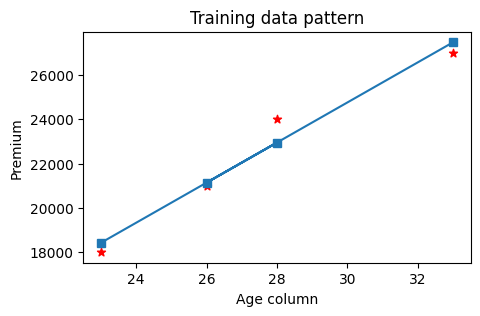

In [178]:
plt.figure(figsize=(5,3))
plt.title('Training data pattern')
plt.xlabel('Age column')
plt.ylabel('Premium')
plt.scatter(x = X_train,y = y_train,color='red',marker='*')
plt.plot(X_train,predict_ans,marker='s')
plt.show()

#test performance

In [179]:
test_predict_ans=reg.predict(X_test)
test_predict_ans

array([13896.22641509, 17518.86792453, 25669.81132075])

In [180]:
Testing_data['test_predict_ans']=test_predict_ans
Testing_data

,X_test,y_test,test_predict_ans
0,18,10000,13896.226415
1,22,15000,17518.867925
5,31,26500,25669.811321


In [181]:
print(r2_score(y_test,test_predict_ans)*100)

84.4834767343119


In [182]:
print(root_mean_squared_error(y_test,test_predict_ans)/100)

27.21181676039746


- Based on the training my model can give 84% accuracy and 27%loss.

#Testing with our own value

- For 29,49,24 age of people how much premium should be given

In [196]:
print(round(reg.predict([[29]])[0],2))

23858.49


In [195]:
print(round(reg.predict([[49]])[0],2))

41971.7


In [194]:
print(round(reg.predict([[24]])[0],2))

19330.19
